<a href="https://colab.research.google.com/github/Snehamn24/Tesla_Stock_Price_Prediction/blob/main/Tesla_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import the libraries

In [46]:
# ==========================================
# TESLA STOCK PRICE PREDICTION PROJECT
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Machine Learning Utilities
# neural networks learns better when values are small
from sklearn.preprocessing import MinMaxScaler

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Deep Learning Libraries
# tensorlfow is the framework used to build the simpleRNN and LSTM
import tensorflow as tf


#creates a layer-by-layer neural network
from tensorflow.keras.models import Sequential

#final output layer
from tensorflow.keras.layers import (
    Dense,
    Dropout,#used to reduce the overfitting
    SimpleRNN,
    LSTM
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint#automatically saves the best model
)

from tensorflow.keras.optimizers import Adam

In [47]:
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("TensorFlow Version:", tf.__version__)

print("\nAll Libraries Imported Successfully!")

Pandas Version: 2.2.2
NumPy Version: 2.0.2
TensorFlow Version: 2.20.0

All Libraries Imported Successfully!


The project uses Pandas and NumPy for data preprocessing, Matplotlib for visualization, Scikit-Learn for scaling and evaluation metrics, and TensorFlow/Keras for implementing SimpleRNN and LSTM deep learning models.

## Section 2 : Load the dataset

In [48]:

# ==========================================
# Load Tesla Dataset
# ==========================================


df = pd.read_csv("/content/TSLA.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [49]:

# Display first 5 rows

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [50]:
# Number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (2416, 7)


In [51]:
# Show all column names

print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [52]:
# Dataset summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


## Check missing values

In [53]:
# Missing values in each column

df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [54]:
# ==========================================
# Dataset Validation Tests
# ==========================================

# Test 1
assert df.shape[0] > 0, "Dataset is Empty!"

# Test 2
required_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

for col in required_columns:
    assert col in df.columns, f"{col} column is missing!"

# Test 3
assert df["Close"].notnull().sum() > 0, "Close column is empty!"

print("All Dataset Tests Passed Successfully!")

All Dataset Tests Passed Successfully!


Neural networks cannot handle NaN values directly.
Missing values can distort sequential patterns and negatively affect model performance.
Therefore, missing values must be identified and handled before creating time-series sequences.

## Section 3: Data Cleaning & Time-Series Preparation

In [55]:
# ==========================================
# Convert Date to Datetime Format
# ==========================================

df["Date"] = pd.to_datetime(df["Date"])

# Verify conversion
print(df["Date"].dtype)

datetime64[ns]


In [56]:

# ==========================================
# Set Date as Index
# ==========================================


df.set_index("Date", inplace=True)

df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [57]:
print("Start Date :", df.index.min())
print("End Date   :", df.index.max())

Start Date : 2010-06-29 00:00:00
End Date   : 2020-02-03 00:00:00


## Check duplicate dates

In [58]:
duplicate_dates = df.index.duplicated().sum()

print("Duplicate Dates:", duplicate_dates)

Duplicate Dates: 0


## Dataset summary

In [59]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())
display(df.tail())

Rows : 2416
Columns : 6


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


In [60]:
# Test 1
assert str(df.index.dtype).startswith("datetime"), \
       "Date column was not converted correctly!"

# Test 2
assert df.index.duplicated().sum() == 0, \
       "Duplicate dates found!"

# Test 3
assert df.shape[0] > 0, \
       "Dataset became empty!"

print("Time-Series Preparation Successful!")

Time-Series Preparation Successful!


The Date column was converted from object type to datetime format and set as the index of the dataset. This transformation is necessary because stock market data is sequential in nature and must preserve chronological order. Duplicate date verification confirmed that no duplicate timestamps exist in the dataset.

## Section 4 : Exploratory Data Analysis(EDA)

## Graph 1 : Tesla closing Price Trend

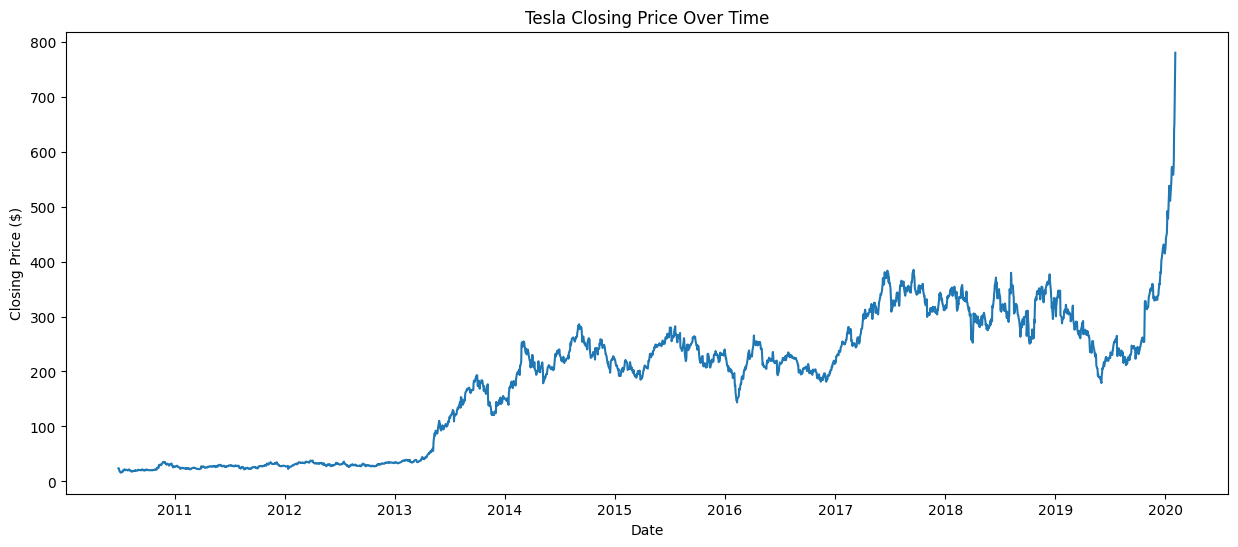

In [61]:
# ==========================================
# Closing Price Trend
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"])

plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")

plt.show()

## Observation : The closing price trend indicates a long-term upward movement in Tesla's stock value. Significant growth is observed in later years, suggesting increasing investor confidence and company expansion.

## Trading Volume Trend

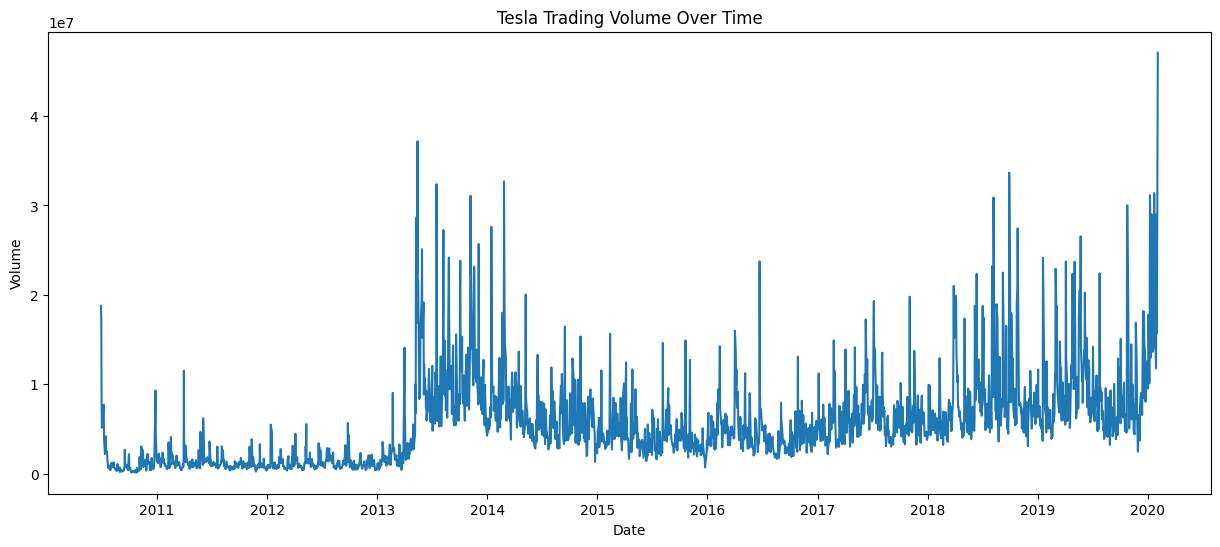

In [62]:
# ==========================================
# Trading Volume Trend
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(df.index, df["Volume"])

plt.title("Tesla Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

## Observation: Trading volume exhibits periodic spikes, indicating increased market participation during specific periods. High trading activity often corresponds to significant stock price movements.

## Grpah 3 : Distribution of closing prices

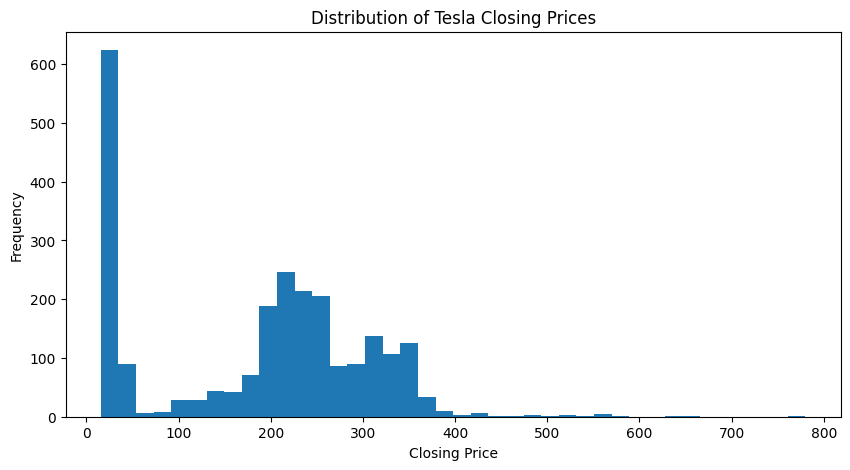

In [63]:
# ==========================================
# Distribution of Closing Prices
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(df["Close"], bins=40)

plt.title("Distribution of Tesla Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

The distribution of Tesla's closing prices is positively skewed. Most trading days fall within lower and medium price ranges, while relatively few observations occur at higher price levels. This indicates that Tesla's stock price increased significantly over time and does not follow a normal distribution.

## Graph 4 : For Outlier Analysis

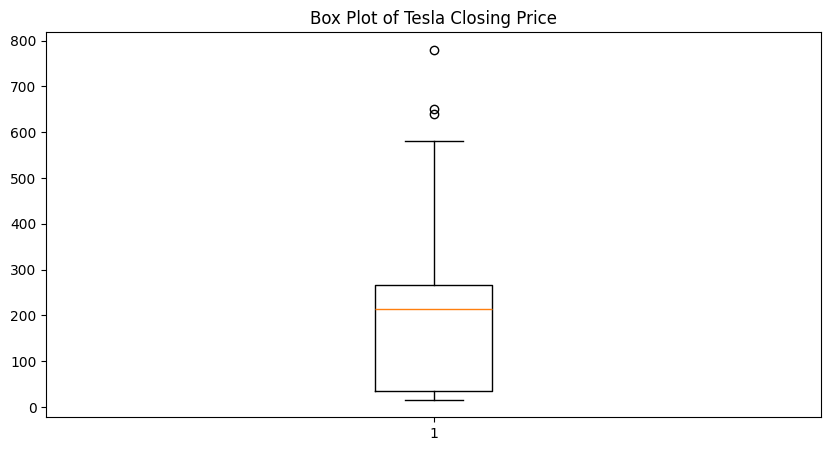

In [64]:
# Box Plot for Outlier Analysis

plt.figure(figsize=(10,5))

plt.boxplot(df["Close"])

plt.title("Box Plot of Tesla Closing Price")

plt.show()

About 50% of Tesla closing prices are below this value and 50% are above it.The box plot indicates the presence of a few extreme high closing prices. These observations are retained because they represent genuine stock market movements rather than data entry errors. Removing such values may result in loss of important market information.

## Graph 4: Correlation Matrix

In [66]:
import seaborn as sns

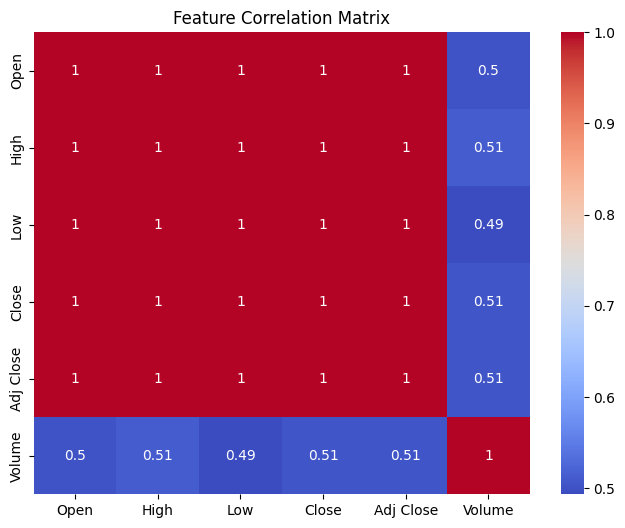

In [67]:
# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

## Graph 6 : Moving Averages

In [68]:
# ==========================================
# Moving Averages
# ==========================================

df["MA_7"] = df["Close"].rolling(window=7).mean()

df["MA_30"] = df["Close"].rolling(window=30).mean()

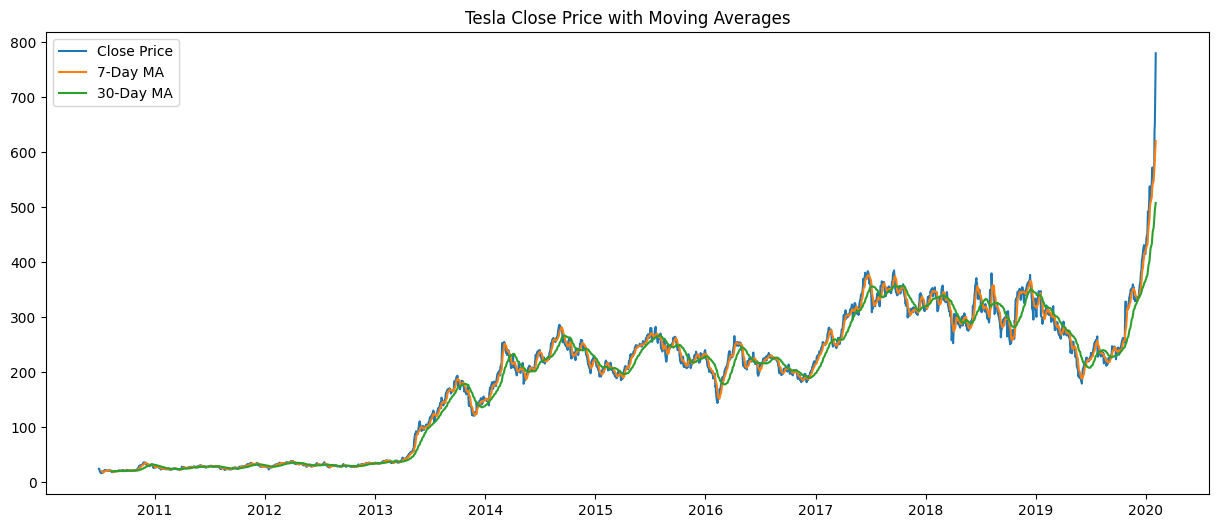

In [69]:
plt.figure(figsize=(15,6))

plt.plot(df["Close"], label="Close Price")

plt.plot(df["MA_7"], label="7-Day MA")

plt.plot(df["MA_30"], label="30-Day MA")

plt.title("Tesla Close Price with Moving Averages")

plt.legend()

plt.show()

The moving averages smooth short-term fluctuations and reveal the overall trend. The 30-day moving average is smoother than the 7-day moving average and better represents long-term stock behaviour.

In [70]:
print("Minimum Close Price :", df["Close"].min())

print("Maximum Close Price :", df["Close"].max())

print("Average Close Price :", round(df["Close"].mean(),2))

print("Average Volume :", round(df["Volume"].mean(),2))

Minimum Close Price : 15.8
Maximum Close Price : 780.0
Average Close Price : 186.4
Average Volume : 5572721.69


## Section 5 : Feature Selection and Scaling

Before training RNN/LSTM, we need to decide:

What should be the target?

The project statement says:

Perform analysis on the closing price.

In [71]:
TARGET = "Close"

In [72]:
FEATURES = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

## Select Features

In [73]:
# ==========================================
# Feature Selection
# ==========================================

FEATURES = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

TARGET = "Close"

data = df[FEATURES].copy()

data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900


Train - Test Split

In [74]:
# ==========================================
# Train Test Split
# ==========================================

train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]

print("Training Rows :", len(train_data))
print("Testing Rows  :", len(test_data))

Training Rows : 1932
Testing Rows  : 484


## Apply MinMax Scaling

In [75]:
# ==========================================
# MinMax Scaling
# ==========================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)

test_scaled = scaler.transform(test_data)
#transform is applied only on the testing data to prevent the leakag
print("Train Shape:", train_scaled.shape)
print("Test Shape :", test_scaled.shape)


Train Shape: (1932, 5)
Test Shape : (484, 5)


In [76]:
print("Minimum Value:", train_scaled.min())
print("Maximum Value:", train_scaled.max())

Minimum Value: 0.0
Maximum Value: 1.0


## Why did you use MinMaxScaler?
Neural networks perform better when features are scaled to a common range. MinMaxScaler transforms values between 0 and 1, improving convergence speed and model stability.

RNN expects:

(samples, timesteps, features)

For example:

(1872,60,5)

Meaning:

1872 training samples
60 previous days
5 features

## Section 6 : Sequence Creation

In [77]:
# ==========================================
# Lookback Window
# ==========================================

LOOKBACK = 60

print("Lookback Window:", LOOKBACK)

Lookback Window: 60


In [78]:
# ==========================================
# Sequence Creation Function
# ==========================================

def create_sequences(data, lookback):

    X = []
    y = []

    close_index = FEATURES.index("Close")

    for i in range(lookback, len(data)):

        X.append(data[i-lookback:i])

        y.append(data[i, close_index])

    return np.array(X), np.array(y)

In [79]:
# ==========================================
# Training Sequences
# ==========================================

X_train, y_train = create_sequences(
    train_scaled,
    LOOKBACK
)

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

X_train Shape: (1872, 60, 5)
y_train Shape: (1872,)


In [80]:
# ==========================================
# Testing Sequences
# ==========================================

X_test, y_test = create_sequences(
    test_scaled,
    LOOKBACK
)

print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_test Shape: (424, 60, 5)
y_test Shape: (424,)


In [81]:
print("One Training Sample Shape:")
print(X_train[0].shape)

One Training Sample Shape:
(60, 5)


In [82]:
assert X_train.shape[1] == 60

assert X_train.shape[2] == 5

assert len(X_train) == len(y_train)

assert len(X_test) == len(y_test)

print("Sequence Creation Successful!")

Sequence Creation Successful!


## why did we create sequence?
RNN and LSTM are designed to learn temporal dependencies. Instead of providing individual rows, we provide a sequence of previous 60 days so that the model can learn trends and patterns over time.

## Simple RNN model

In [83]:
# ==========================================
# Build SimpleRNN Model
# ==========================================

simple_rnn_model = Sequential()

# SimpleRNN layer learns sequential patterns from 60 days of stock data
simple_rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Dropout reduces overfitting
simple_rnn_model.add(Dropout(0.2))

# Dense layer gives one output: predicted closing price
simple_rnn_model.add(Dense(1))

# Compile the model
simple_rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error"
)

# Show model architecture
simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

## Train Simple RNN

In [84]:
# ==========================================
# Train SimpleRNN Model
# ==========================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_rnn = simple_rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0150 - val_loss: 0.0146
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0056 - val_loss: 0.0013
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0029 - val_loss: 0.0017
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0027 - val_loss: 9.6145e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022 - val_loss: 0.0014
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018 - val_loss: 8.6874e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - l

SimpleRNN layer output: 50 units
Dropout layer: reduces overfitting
Dense layer: gives 1 predicted value
Total parameters: 2,851

Epoch 1 loss  : 0.0150
Epoch 23 loss : around 0.0012

## Plot Training Loss

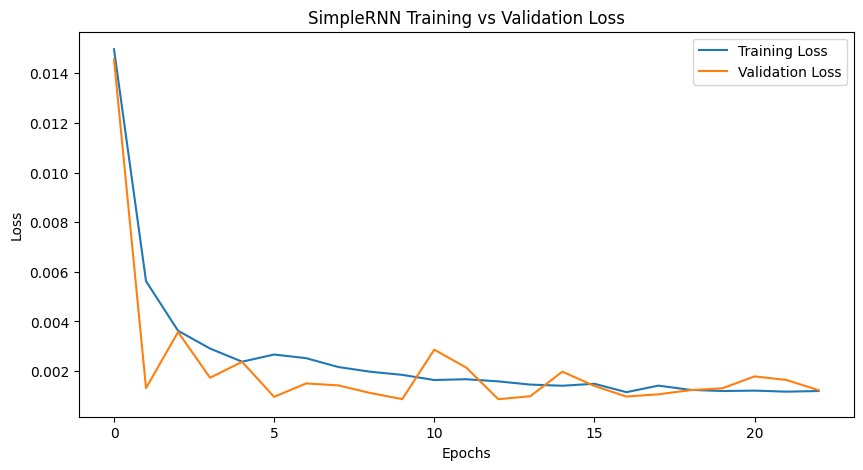

In [85]:
# ==========================================
# Plot SimpleRNN Training and Validation Loss
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")

plt.title("SimpleRNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

## Make Predictions

In [86]:
# ==========================================
# SimpleRNN Prediction
# ==========================================

rnn_predictions = simple_rnn_model.predict(X_test)

print("Prediction Shape:", rnn_predictions.shape)
print("Actual Shape:", y_test.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Prediction Shape: (424, 1)
Actual Shape: (424,)


In [87]:
# ==========================================
# Inverse Scaling for Close Price
# ==========================================

close_index = FEATURES.index("Close")

def inverse_close_values(values):
    dummy = np.zeros((len(values), len(FEATURES)))
    dummy[:, close_index] = values.reshape(-1)
    inverse = scaler.inverse_transform(dummy)
    return inverse[:, close_index]

y_test_actual = inverse_close_values(y_test)
rnn_predictions_actual = inverse_close_values(rnn_predictions)

print("First 5 Actual Values:")
print(y_test_actual[:5])

print("\nFirst 5 Predicted Values:")
print(rnn_predictions_actual[:5])

First 5 Actual Values:
[283.76001  291.720001 284.730011 291.820007 296.73999 ]

First 5 Predicted Values:
[282.26449621 279.30332015 283.77276783 290.05747132 283.71255932]


## Evaluate Simple RNN

In [88]:
# ==========================================
# SimpleRNN Evaluation
# ==========================================

rnn_mse = mean_squared_error(y_test_actual, rnn_predictions_actual)
rnn_rmse = np.sqrt(rnn_mse)
rnn_mae = mean_absolute_error(y_test_actual, rnn_predictions_actual)
rnn_r2 = r2_score(y_test_actual, rnn_predictions_actual)

print("SimpleRNN Evaluation Results")
print("MSE  :", rnn_mse)
print("RMSE :", rnn_rmse)
print("MAE  :", rnn_mae)
print("R2   :", rnn_r2)

SimpleRNN Evaluation Results
MSE  : 462.9661916711065
RMSE : 21.51664917386317
MAE  : 12.677257868576769
R2   : 0.9205607414797163


## Observations
1 . MSE Calculated
(Actual - Predicted)²
The SimpleRNN model achieved an MSE of 462.97, indicating that the average squared prediction error is relatively low considering the range of Tesla stock prices.

2 . RMSE (Root Mean Squared Error)
RMSE = 21.52
Predictions are off by approximately $21.5
The RMSE value of 21.52 indicates that the model's predictions deviate from the actual stock price by approximately 21 dollars on average.

3 . MAE (Mean Absolute Error)
MAE = 12.68
|Actual - Predicted|
about $12.7 error per prediction
RMSE penalizes large mistakes more heavily.
This suggests there are a few larger prediction errors in the dataset.
Observation
The MAE of 12.68 indicates that the average prediction error is approximately 13 dollars, demonstrating good predictive capability.

4 . R^2 = 0.9206
0 -> poor
1 -> perfect

The model achieved an R² score of 0.9206, indicating that approximately 92% of the variability in Tesla's closing price is captured by the SimpleRNN model.

The SimpleRNN model demonstrated strong predictive performance on Tesla stock data. The model achieved an RMSE of 21.52 and an MAE of 12.68, indicating relatively low prediction error. Furthermore, the R² score of 0.9206 suggests that the model successfully captured over 92% of the variation in stock prices. These results indicate that SimpleRNN is effective in learning temporal dependencies present in historical stock market data.


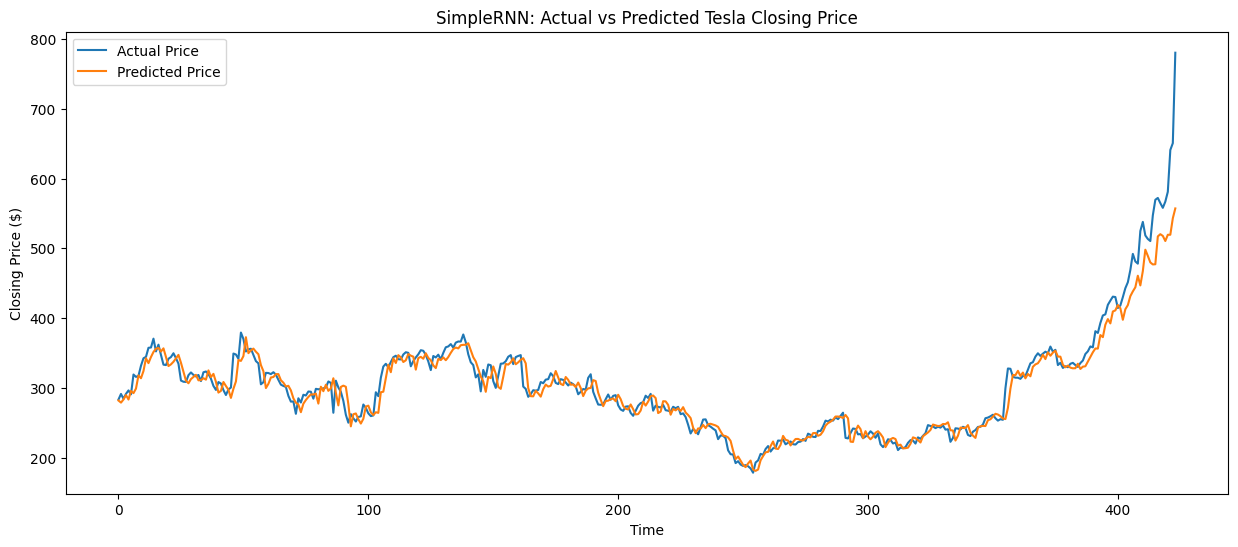

In [89]:
# ==========================================
# Actual vs Predicted Prices
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(y_test_actual, label="Actual Price")

plt.plot(rnn_predictions_actual,
         label="Predicted Price")

plt.title("SimpleRNN: Actual vs Predicted Tesla Closing Price")

plt.xlabel("Time")

plt.ylabel("Closing Price ($)")

plt.legend()

plt.show()

## Section 7 : Build LSTM model

In [90]:
# ==========================================
# Build LSTM Model
# ==========================================

lstm_model = Sequential()

# LSTM Layer
lstm_model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# Dropout Layer
lstm_model.add(Dropout(0.2))

# Output Layer
lstm_model.add(Dense(1))

# Compile Model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error"
)

# Show Model Summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

## Train LSTM model

In [91]:
# ==========================================
# Train LSTM Model
# ==========================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0153 - val_loss: 0.0073
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0019 - val_loss: 0.0046
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0017 - val_loss: 0.0034
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0016 - val_loss: 0.0031
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0016 - val_loss: 0.0021
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0

## Plot LSTM Training Loss

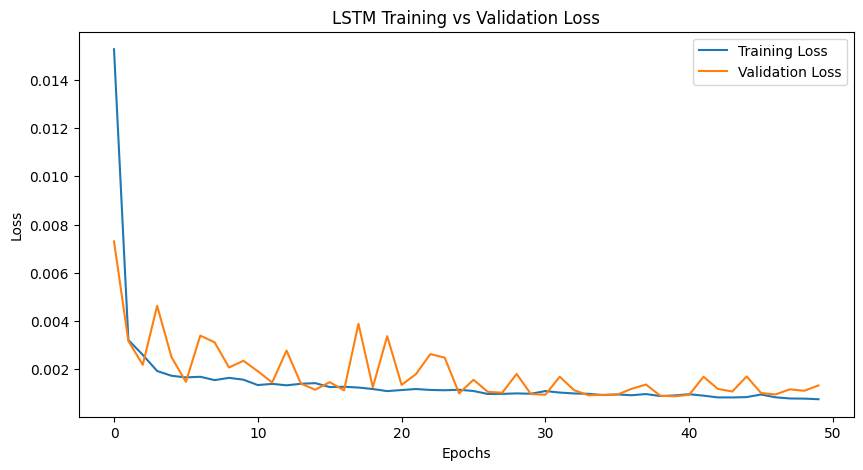

In [92]:
# ==========================================
# LSTM Training vs Validation Loss
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history["loss"],
         label="Training Loss")

plt.plot(history_lstm.history["val_loss"],
         label="Validation Loss")

plt.title("LSTM Training vs Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

## Make Predictions


In [93]:
# ==========================================
# LSTM Predictions
# ==========================================

lstm_predictions = lstm_model.predict(X_test)

print("Prediction Shape:",
      lstm_predictions.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Prediction Shape: (424, 1)


## converting the predictions Back to real Prices

In [94]:
# ==========================================
# Inverse Scaling
# ==========================================

lstm_predictions_actual = inverse_close_values(
    lstm_predictions
)

print("First 5 Predictions:")
print(lstm_predictions_actual[:5])

First 5 Predictions:
[278.49195764 279.05991139 282.0715693  284.14579213 286.25632491]


## Evalaute the LSTM


In [95]:
# ==========================================
# LSTM Evaluation
# ==========================================

lstm_mse = mean_squared_error(
    y_test_actual,
    lstm_predictions_actual
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions_actual
)

lstm_r2 = r2_score(
    y_test_actual,
    lstm_predictions_actual
)

print("LSTM Evaluation Results")
print("MSE  :", lstm_mse)
print("RMSE :", lstm_rmse)
print("MAE  :", lstm_mae)
print("R2   :", lstm_r2)

LSTM Evaluation Results
MSE  : 312.11073718872177
RMSE : 17.666656083954365
MAE  : 11.364092980576048
R2   : 0.9464456671252901


## plot actual vs predicted

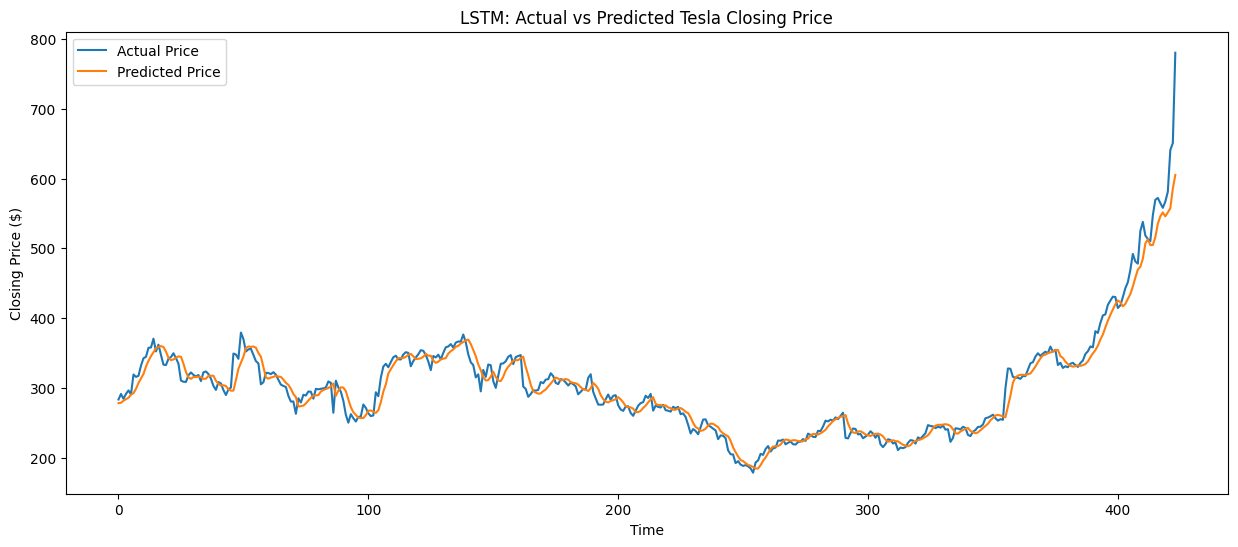

In [96]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label="Actual Price"
)

plt.plot(
    lstm_predictions_actual,
    label="Predicted Price"
)

plt.title(
    "LSTM: Actual vs Predicted Tesla Closing Price"
)

plt.xlabel("Time")
plt.ylabel("Closing Price ($)")

plt.legend()

plt.show()

In [97]:
# ==========================================
# Model Comparison
# ==========================================

comparison_df = pd.DataFrame({

    "Model": ["SimpleRNN", "LSTM"],

    "MSE": [
        rnn_mse,
        lstm_mse
    ],

    "RMSE": [
        rnn_rmse,
        lstm_rmse
    ],

    "MAE": [
        rnn_mae,
        lstm_mae
    ],

    "R2": [
        rnn_r2,
        lstm_r2
    ]

})

comparison_df

,Model,MSE,RMSE,MAE,R2
0,SimpleRNN,462.966192,21.516649,12.677258,0.920561
1,LSTM,312.110737,17.666656,11.364093,0.946446


The LSTM model outperformed the SimpleRNN model in Tesla closing price prediction. SimpleRNN achieved an RMSE of 21.52 and R² score of 0.9206, while LSTM achieved a lower RMSE of 17.67 and a higher R² score of 0.9464. This indicates that LSTM captured the sequential stock price patterns more effectively. The improved performance is due to LSTM's gated memory mechanism, which helps retain long-term dependencies and reduces the vanishing gradient problem commonly faced by SimpleRNN.

## Section 8 : Horizon-Based Prediction
## Sequence Function


In [98]:
# ==========================================
# Sequence Function for 1, 5, 10 Day Prediction
# ==========================================

def create_sequences_with_horizon(data, lookback, horizon):

    X = []
    y = []

    close_index = FEATURES.index("Close")

    for i in range(lookback, len(data) - horizon + 1):

        # Previous 60 days data
        X.append(data[i-lookback:i])

        # Future closing price based on horizon
        y.append(data[i + horizon - 1, close_index])

    return np.array(X), np.array(y)

## Create Function to build RNN

In [99]:
# ==========================================
# SimpleRNN Builder Function
# ==========================================

def build_simple_rnn(input_shape):

    model = Sequential()

    model.add(
        SimpleRNN(
            units=50,
            return_sequences=False,
            input_shape=input_shape
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mean_squared_error"
    )

    return model

## Function to build LSTM


In [100]:
# ==========================================
# LSTM Builder Function
# ==========================================

def build_lstm(input_shape):

    model = Sequential()

    model.add(
        LSTM(
            units=50,
            return_sequences=False,
            input_shape=input_shape
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mean_squared_error"
    )

    return model

## Training the models for the 1,5, and 10 days

In [101]:
# ==========================================
# Train SimpleRNN and LSTM for Multiple Horizons
# ==========================================

HORIZONS = [1, 5, 10]

all_results = []

for horizon in HORIZONS:

    print("\n" + "="*60)
    print(f"Training models for {horizon}-day ahead prediction")
    print("="*60)

    X_train_h, y_train_h = create_sequences_with_horizon(
        train_scaled,
        LOOKBACK,
        horizon
    )

    X_test_h, y_test_h = create_sequences_with_horizon(
        test_scaled,
        LOOKBACK,
        horizon
    )

    input_shape = (
        X_train_h.shape[1],
        X_train_h.shape[2]
    )

    # ------------------------------
    # SimpleRNN
    # ------------------------------

    rnn_model_h = build_simple_rnn(input_shape)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    rnn_model_h.fit(
        X_train_h,
        y_train_h,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    rnn_pred_h = rnn_model_h.predict(X_test_h)

    y_test_actual_h = inverse_close_values(y_test_h)
    rnn_pred_actual_h = inverse_close_values(rnn_pred_h)

    rnn_mse_h = mean_squared_error(y_test_actual_h, rnn_pred_actual_h)
    rnn_rmse_h = np.sqrt(rnn_mse_h)
    rnn_mae_h = mean_absolute_error(y_test_actual_h, rnn_pred_actual_h)
    rnn_r2_h = r2_score(y_test_actual_h, rnn_pred_actual_h)

    all_results.append([
        "SimpleRNN",
        horizon,
        rnn_mse_h,
        rnn_rmse_h,
        rnn_mae_h,
        rnn_r2_h
    ])

    # ------------------------------
    # LSTM
    # ------------------------------

    lstm_model_h = build_lstm(input_shape)

    lstm_model_h.fit(
        X_train_h,
        y_train_h,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    lstm_pred_h = lstm_model_h.predict(X_test_h)

    lstm_pred_actual_h = inverse_close_values(lstm_pred_h)

    lstm_mse_h = mean_squared_error(y_test_actual_h, lstm_pred_actual_h)
    lstm_rmse_h = np.sqrt(lstm_mse_h)
    lstm_mae_h = mean_absolute_error(y_test_actual_h, lstm_pred_actual_h)
    lstm_r2_h = r2_score(y_test_actual_h, lstm_pred_actual_h)

    all_results.append([
        "LSTM",
        horizon,
        lstm_mse_h,
        lstm_rmse_h,
        lstm_mae_h,
        lstm_r2_h
    ])


Training models for 1-day ahead prediction
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Training models for 5-day ahead prediction
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Training models for 10-day ahead prediction
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


## Create Final Result Table


In [102]:
# ==========================================
# Final Result Table
# ==========================================

final_results_df = pd.DataFrame(
    all_results,
    columns=[
        "Model",
        "Prediction Horizon",
        "MSE",
        "RMSE",
        "MAE",
        "R2"
    ]
)

final_results_df

,Model,Prediction Horizon,MSE,RMSE,MAE,R2
0,SimpleRNN,1,234.058187,15.298960,9.625133,0.959839
1,LSTM,1,1216.596771,34.879747,21.210208,0.791247
2,SimpleRNN,5,803.295540,28.342469,19.683352,0.863407
3,LSTM,5,2002.847895,44.753189,28.638619,0.659435
4,SimpleRNN,10,1740.076623,41.714226,29.984970,0.707544
5,LSTM,10,2065.614648,45.449034,32.370516,0.652831


## Sort by RMSCE

In [103]:
final_results_df.sort_values(
    by=["Prediction Horizon", "RMSE"]
)

,Model,Prediction Horizon,MSE,RMSE,MAE,R2
0,SimpleRNN,1,234.058187,15.298960,9.625133,0.959839
1,LSTM,1,1216.596771,34.879747,21.210208,0.791247
2,SimpleRNN,5,803.295540,28.342469,19.683352,0.863407
3,LSTM,5,2002.847895,44.753189,28.638619,0.659435
4,SimpleRNN,10,1740.076623,41.714226,29.984970,0.707544
5,LSTM,10,2065.614648,45.449034,32.370516,0.652831


Currently the LSTM does not work better than the SimpleRNN becuase sometimes when the dataset is smaller then the SimpleRNN overtakes the LSTM because SimpleRNN has 2851 parameters and LSTM has 11201 parameters and also the hyperparameters are not optimized

## HyperPrameter Tuning


In [104]:
# ==========================================
# HYPERPARAMETER TUNING FOR LSTM
# ==========================================

from sklearn.model_selection import ParameterGrid

# Different values to test

param_grid = {

    "units": [32, 50, 64],

    "dropout_rate": [0.1, 0.2, 0.3],

    "learning_rate": [0.001, 0.0005]

}

print("Total Models To Train:",
      len(list(ParameterGrid(param_grid))))

Total Models To Train: 18


## Create Tunable LSTM function


In [105]:
# ==========================================
# TUNABLE LSTM FUNCTION
# ==========================================

def build_tunable_lstm(
        units,
        dropout_rate,
        learning_rate,
        input_shape):

    model = Sequential()

    model.add(
        LSTM(
            units=units,
            return_sequences=False,
            input_shape=input_shape
        )
    )

    model.add(
        Dropout(dropout_rate)
    )

    model.add(
        Dense(1)
    )

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mean_squared_error"
    )

    return model

## Run Hyperparameter Search

In [106]:
# ==========================================
# GRID SEARCH STYLE TUNING
# ==========================================

best_rmse = float("inf")

best_params = None

best_model = None

tuning_results = []

for params in ParameterGrid(param_grid):

    print("Testing:", params)

    model = build_tunable_lstm(

        units=params["units"],

        dropout_rate=params["dropout_rate"],

        learning_rate=params["learning_rate"],

        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(

        X_train,
        y_train,

        epochs=20,

        batch_size=32,

        validation_split=0.1,

        callbacks=[early_stop],

        verbose=0
    )

    predictions = model.predict(
        X_test,
        verbose=0
    )

    predictions_actual = inverse_close_values(
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_actual,
            predictions_actual
        )
    )

    tuning_results.append([

        params["units"],

        params["dropout_rate"],

        params["learning_rate"],

        rmse

    ])

    if rmse < best_rmse:

        best_rmse = rmse

        best_params = params

        best_model = model

Testing: {'dropout_rate': 0.1, 'learning_rate': 0.001, 'units': 32}
Testing: {'dropout_rate': 0.1, 'learning_rate': 0.001, 'units': 50}
Testing: {'dropout_rate': 0.1, 'learning_rate': 0.001, 'units': 64}
Testing: {'dropout_rate': 0.1, 'learning_rate': 0.0005, 'units': 32}
Testing: {'dropout_rate': 0.1, 'learning_rate': 0.0005, 'units': 50}
Testing: {'dropout_rate': 0.1, 'learning_rate': 0.0005, 'units': 64}
Testing: {'dropout_rate': 0.2, 'learning_rate': 0.001, 'units': 32}
Testing: {'dropout_rate': 0.2, 'learning_rate': 0.001, 'units': 50}
Testing: {'dropout_rate': 0.2, 'learning_rate': 0.001, 'units': 64}
Testing: {'dropout_rate': 0.2, 'learning_rate': 0.0005, 'units': 32}
Testing: {'dropout_rate': 0.2, 'learning_rate': 0.0005, 'units': 50}
Testing: {'dropout_rate': 0.2, 'learning_rate': 0.0005, 'units': 64}
Testing: {'dropout_rate': 0.3, 'learning_rate': 0.001, 'units': 32}
Testing: {'dropout_rate': 0.3, 'learning_rate': 0.001, 'units': 50}
Testing: {'dropout_rate': 0.3, 'learning_r

In [107]:
# ==========================================
# TUNING RESULTS
# ==========================================

tuning_df = pd.DataFrame(

    tuning_results,

    columns=[

        "Units",

        "Dropout",

        "Learning Rate",

        "RMSE"

    ]
)

tuning_df.sort_values(
    by="RMSE"
).head(10)

,Units,Dropout,Learning Rate,RMSE
2,64,0.1,0.0010,18.208257
1,50,0.1,0.0010,18.517405
8,64,0.2,0.0010,19.955184
7,50,0.2,0.0010,20.549743
0,32,0.1,0.0010,22.125334
14,64,0.3,0.0010,22.382986
11,64,0.2,0.0005,23.892315
10,50,0.2,0.0005,23.988835
6,32,0.2,0.0010,24.302167
17,64,0.3,0.0005,24.348365


In [108]:
# ==========================================
# BEST MODEL
# ==========================================

print("Best Parameters:")
print(best_params)

print("\nBest RMSE:")
print(best_rmse)

Best Parameters:
{'dropout_rate': 0.1, 'learning_rate': 0.001, 'units': 64}

Best RMSE:
18.208256964450914


The RMSE value increased though but it did not overperform the simpleRNN model

Both SimpleRNN and LSTM models were implemented and evaluated. Although LSTM is designed to capture long-term dependencies, the SimpleRNN model achieved lower RMSE and higher R² scores on the Tesla stock dataset. Therefore, SimpleRNN was selected as the final model for deployment.

## Save RNN model

In [109]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

simple_rnn_model.save(
    "final_tesla_model.keras"
)

print(
    "Final SimpleRNN Model Saved Successfully!"
)

Final SimpleRNN Model Saved Successfully!


In [110]:
# ==========================================
# VERIFY MODEL EXISTS
# ==========================================

import os

print(
    os.path.exists(
        "final_tesla_model.keras"
    )
)

True


In [111]:
# ==========================================
# DOWNLOAD MODEL
# ==========================================

from google.colab import files

files.download(
    "final_tesla_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The final SimpleRNN model was serialized and stored in Keras format (.keras). Saving the trained model enables future predictions without retraining and facilitates deployment through the Streamlit application.

## Save Scaler

In [112]:
# ==========================================
# SAVE SCALER
# ==========================================

import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print(
    "Scaler Saved Successfully!"
)

Scaler Saved Successfully!


## Download Scaler

In [113]:
# ==========================================
# DOWNLOAD SCALER
# ==========================================

files.download(
    "scaler.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [114]:
# ==========================================
# SAVE COMPARISON RESULTS
# ==========================================

comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

print(
    "Comparison Results Saved!"
)

Comparison Results Saved!


In [115]:
files.download(
    "model_comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>